In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
## Loading dataset
df = pd.read_csv(r"E:\InnoML_531\nyc_taxi_trip_duration.csv",
    dtype={
        "vendor_id": "int8",
        "passenger_count": "int8",
        "store_and_fwd_flag": "category",
        "pickup_longitude": "float32",
        "pickup_latitude": "float32",
        "dropoff_longitude": "float32",
        "dropoff_latitude": "float32",
        "trip_duration": "int32"
    },
    parse_dates=["pickup_datetime", "dropoff_datetime"]
)




In [3]:
df.shape
## 729322 entries with 11 features 
## Total trips --->729322

(729322, 11)

In [4]:
df.info()
##Trip details with different dates ,hours, with pickup and drop loacations (latitude, logitudes), trip duration from two vendors 


<class 'pandas.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  str           
 1   vendor_id           729322 non-null  int8          
 2   pickup_datetime     729322 non-null  datetime64[us]
 3   dropoff_datetime    729322 non-null  datetime64[us]
 4   passenger_count     729322 non-null  int8          
 5   pickup_longitude    729322 non-null  float32       
 6   pickup_latitude     729322 non-null  float32       
 7   dropoff_longitude   729322 non-null  float32       
 8   dropoff_latitude    729322 non-null  float32       
 9   store_and_fwd_flag  729322 non-null  category      
 10  trip_duration       729322 non-null  int32         
dtypes: category(1), datetime64[us](2), float32(4), int32(1), int8(2), str(1)
memory usage: 32.7 MB


In [5]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

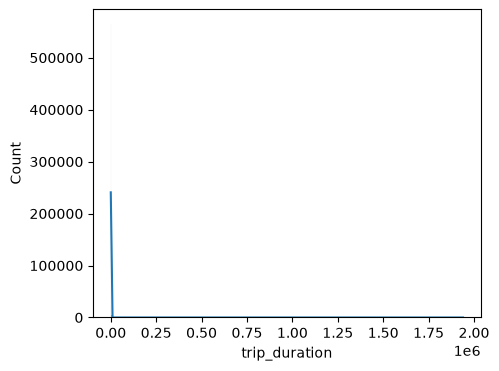

In [7]:
plt.figure(figsize = (5,4))
sns.histplot(df['trip_duration'],kde = True)
plt.show()
## Trip duration is right skewed ... says that data contains long trips too!! 

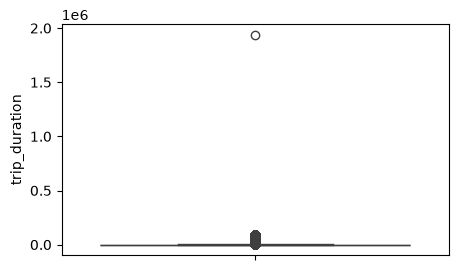

In [8]:
plt.figure(figsize = (5,3))
sns.boxplot(df['trip_duration'])
plt.show()


In [9]:
## pickup

def extract_features_date(col,about):
    df[about+'_year'] = df[col].dt.year ## Extract year
    df[about+'_month']=df[col].dt.month ## extract date
    df[about+'_day_of_week'] = df[col].dt.day_of_week## Extract day name 
    df[about+'_day_of_month'] = df[col].dt.day##Extract date
    df[about+'_hour']  = df[col].dt.hour  ## Extract pick Hour of the trip
    df[about+'_minute'] = df[col].dt.minute ## Extract pick minutes 
    

In [10]:
## extracting features like week day, year, hour, minute, month etc from pickup_datetime 
extract_features_date(col = 'pickup_datetime', about = 'pickup')


In [11]:
extract_features_date(col = 'dropoff_datetime', about = 'drop')

In [12]:
print(df.shape)
pd.set_option('display.max_columns', None)
df.head()
## After Extracting the feaatures like date, monh, hour etc ... I ended up with 23 features 

(729322, 23)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day_of_week,pickup_day_of_month,pickup_hour,pickup_minute,drop_year,drop_month,drop_day_of_week,drop_day_of_month,drop_hour,drop_minute
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400,2016,2,0,29,16,40,2016,2,0,29,16,47
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100,2016,3,4,11,23,35,2016,3,4,11,23,53
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635,2016,2,6,21,17,59,2016,2,6,21,18,26
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141,2016,1,1,5,9,44,2016,1,1,5,10,3
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848,2016,2,2,17,6,42,2016,2,2,17,6,56


### EDA Insights

In [13]:
df['vendor_id'].value_counts()
## Vendor 2  with more no .of trips

vendor_id
2    390481
1    338841
Name: count, dtype: int64

In [14]:
df['passenger_count'].value_counts()
## 33 times taxi travelled with 0 passengers
## only one trip with more no.of (9)  passengers
## In year 2016 most of the trips were held with 1 , 2 passengers

## trip with 0 passengers might be a data quality error

passenger_count
1    517415
2    105097
5     38926
3     29692
6     24107
4     14050
0        33
7         1
9         1
Name: count, dtype: int64

In [15]:
print(df['pickup_year'].value_counts())
print(df['drop_year'].value_counts())

## the data belongs to the year 2016

pickup_year
2016    729322
Name: count, dtype: int64
drop_year
2016    729322
Name: count, dtype: int64


In [16]:
df['pickup_month'].value_counts()
## March has more no.of pickups

pickup_month
3    128316
4    125634
5    124201
2    119364
6    117406
1    114401
Name: count, dtype: int64

In [17]:
df['drop_month'].value_counts()
## Observed different no of pickups and dropoff counts according to the month is due to midnight trips , day changes by hour of pick and droping
## so in drop_month feature we are able to see july

## more no of trips were held in the month of march

drop_month
3    128284
4    125633
5    124236
2    119361
6    117380
1    114375
7        53
Name: count, dtype: int64

In [18]:
df[df['drop_month']==7][['drop_day_of_month','drop_day_of_week']].nunique()

drop_day_of_month    1
drop_day_of_week     1
dtype: int64

In [23]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_year', 'pickup_month', 'pickup_day_of_week',
       'pickup_day_of_month', 'pickup_hour', 'pickup_minute', 'drop_year',
       'drop_month', 'drop_day_of_week', 'drop_day_of_month', 'drop_hour',
       'drop_minute'],
      dtype='str')

In [24]:
df[df['drop_month']==7][['drop_day_of_month','drop_day_of_week']].head(1)

## Data is up to july 1 2016

,drop_day_of_month,drop_day_of_week
7618,1,4


In [27]:
## Finding on which days trips were held in week days or weekends 
display(df['pickup_day_of_week'].value_counts())


## 0----> Monday
## 1---->Tuesday
## 2---->Wednesday
## 3---->Thursday
## 4---->Friday
## 5---->Saturday
## 6---->Sunday

pickup_day_of_week
4    111744
5    110252
3    109344
2    105074
1    101254
6     97682
0     93972
Name: count, dtype: int64

In [ ]:
## most of the trips were held on friday 
# but the counts of pickup , dropoff are not same , these differences may be due to pickup, dropoff hours   
# On monday there are least no.of trips compared to other days in a week

## more  pickups are at the end of the friday

## less no.of trips on monday

In [28]:
df['pickup_hour'].value_counts().head(5)
## Peak hours where people tries to travel in a taxi

pickup_hour
18    45404
19    45262
20    42165
21    42045
22    40293
Name: count, dtype: int64

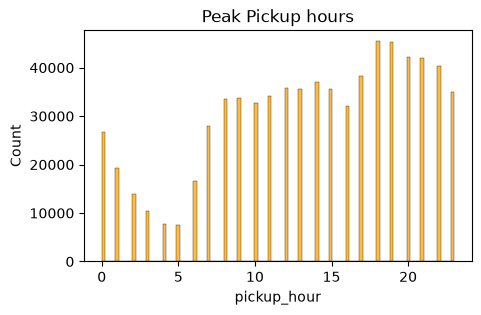

In [29]:
plt.figure(figsize= (5,3))
sns.histplot(df['pickup_hour'],color = 'orange')
plt.title('Peak Pickup hours')
plt.show()

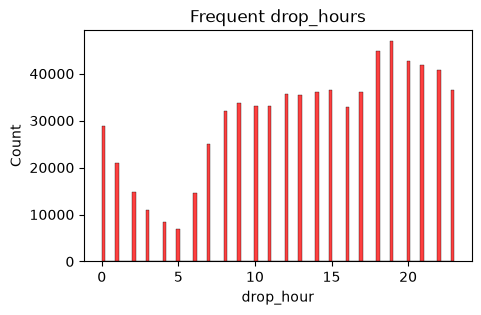

In [30]:
plt.figure(figsize  =(5,3))
sns.histplot(df['drop_hour'],color  = 'red')
plt.title('Frequent drop_hours')
plt.show()

In [31]:
## most of the pickups and drops are from afternoon to end of the day 
# Very less trip in the from mid night to morning hours 
# The trips are gradually increasing after 5 am- 3 pm , observed silightly decrement at 4-5pm , increased at approximately 6 to 7 pm 


In [32]:
pd.DataFrame(df['pickup_day_of_month'].value_counts()).head(10)

,count
pickup_day_of_month,
16,25519
14,25206
12,25156
15,25037
5,25030
4,24958
6,24757
9,24729
13,24649


In [33]:
## Observed more pickups and drops on the days 16,14,12,15
## very less trips on days : 30,31 (end of the month)

In [37]:
## Calculating distance

from distance_utils import calculate_distance

df['distance(km)'] = calculate_distance(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

In [40]:
df.head(1)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day_of_week,pickup_day_of_month,pickup_hour,pickup_minute,drop_year,drop_month,drop_day_of_week,drop_day_of_month,drop_hour,drop_minute,distance(km)
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400,2016,2,0,29,16,40,2016,2,0,29,16,47,1.199073


In [41]:
df['distance(km)'].shape[0]

729322

In [32]:
df['distance(km)'].isnull().sum()

np.int64(0)

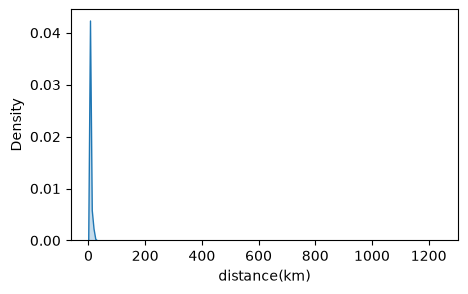

In [42]:
plt.figure(figsize = (5,3))
sns.kdeplot(df['distance(km)'],fill =True)
plt.show()



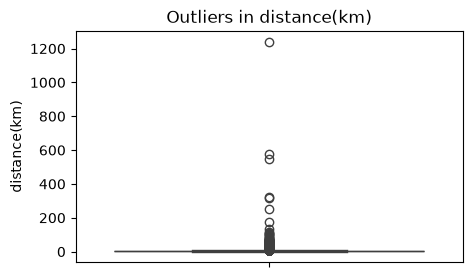

In [43]:
plt.figure(figsize = (5,3))
sns.boxplot(df['distance(km)'])
plt.title("Outliers in distance(km)")
plt.show()

## This shows most of the trips are densed at below 100 km ,some of the trips are with long distances

In [44]:
df['distance(km)'].describe()
## Trips with maximum distance -----------------> 1240 km
## average distance covered by NYC Taxi's ------> 3.44 km
## The minimum distance covered is 0km
## The median of the distance  -----------------> 2.09 km
## this shows , where the mean is greater than the median ... says the distance  have extreme values (long trips)

count    729322.000000
mean          3.441139
std           4.353132
min           0.000000
25%           1.232695
50%           2.095672
75%           3.876481
max        1240.908691
Name: distance(km), dtype: float64

In [45]:
df[df['distance(km)']<=40].shape
## Less than or equal to 40 km

(729224, 24)

In [46]:
df[df['distance(km)']>40].shape
## Trips with greater than  40 km

(98, 24)

In [47]:
df[df['distance(km)']<0].shape
# trips with less than 0km

(0, 24)

In [48]:
df[df['distance(km)']==0].shape
# 2901 trips with  0km
# distance cannot be zero

(2901, 24)

In [49]:
distance_zero_km = df[df['distance(km)']==0][['pickup_longitude','dropoff_longitude','pickup_latitude','dropoff_latitude','trip_duration']]

print(distance_zero_km.shape)
distance_zero_km.head()
## Cross check data ------> where distance is zero ===> pickup & dropoff logitudes are same , trips trip_duration is greater than zero

(2901, 5)


,pickup_longitude,dropoff_longitude,pickup_latitude,dropoff_latitude,trip_duration
263,-73.996422,-73.996422,40.298828,40.298828,240
327,-73.996323,-73.996323,40.753460,40.753460,159
795,-73.967171,-73.967171,40.763500,40.763500,897
1176,-73.995232,-73.995232,40.744038,40.744038,256
1257,-73.912781,-73.912781,40.804428,40.804428,1330


In [50]:
df[(df['pickup_longitude']== df['dropoff_longitude']) & (df['pickup_latitude']==df['dropoff_latitude'])].shape

## pickup & drop location is same 



(2901, 24)

In [51]:
df['trip_duration'].corr(df['distance(km)'])

np.float64(0.12577168753649598)

In [52]:
df[(df['trip_duration']<=30)& (df['distance(km)']==0)].shape
## 644 trips with duration less than 30 sec where distance is 0km-- seems to be a data error 

(644, 24)

In [53]:
data = df.drop(['pickup_year','drop_year'],axis = 1).corr(numeric_only = True)
data['trip_duration']
# moderation relation b/w pickup logitude and dropoff longitude
# pickup_logitude with trip_duaration  being close to zero does not mean pickup longitude isn't useful.
# The relationship can be nonlinear and spatial.

vendor_id              0.027752
passenger_count        0.013022
pickup_longitude       0.035447
pickup_latitude       -0.038163
dropoff_longitude      0.020664
dropoff_latitude      -0.028283
trip_duration          1.000000
pickup_month           0.009378
pickup_day_of_week    -0.002302
pickup_day_of_month    0.000999
pickup_hour            0.002979
pickup_minute         -0.004084
drop_month             0.010135
drop_day_of_week      -0.003369
drop_day_of_month      0.001701
drop_hour              0.003027
drop_minute           -0.005404
distance(km)           0.125772
Name: trip_duration, dtype: float64

In [54]:
# ouliers in trip_duration --- target col

q1 = df['trip_duration'].quantile(0.25)
q3 = df['trip_duration'].quantile(0.75)

iqr = q3-q1

ll = q1-(1.5*iqr)
ul = q3+(1.5*iqr)



outliers = df[(df['trip_duration'] <=ll) | (df['trip_duration']>=ul)]
print('Total Outliers :',outliers.shape[0])
outliers['trip_duration'].describe()

## 37012 are the extreme long / short trips 

Total Outliers : 37012


count    3.701200e+04
mean     5.070632e+03
std      1.651315e+04
min      2.092000e+03
25%      2.307000e+03
50%      2.623000e+03
75%      3.216000e+03
max      1.939736e+06
Name: trip_duration, dtype: float64

In [55]:
#----> Data collected from January - June(pickups) of year 2016
#----> Vendor 2 is high.
#----> More no.of trips with single passenger, observed a single trip with 9 passengers 
#----> 33 times a taxi travelled with (0) no passengers 
#----> More no.of  trips were placed on Friday , Saturday , Thursday , least no.of trips on Monday
#----> observed more pickups and drops  on dates 16,14,12
#----> Average distance covered by the NYC taxi --> 3.4411
#----> 729224 Trips are with less than or equal to 40 km+

## General EDA Questions 

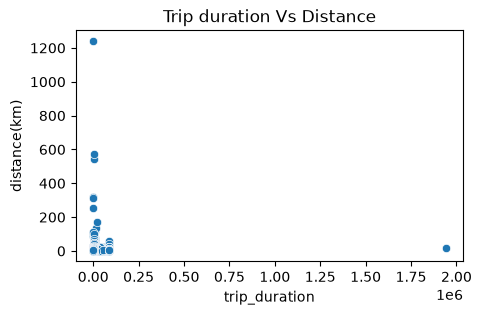

In [56]:
## Trip duration Vs distance 
plt.figure(figsize = (5,3))
sns.scatterplot(x =df['trip_duration'],y = df['distance(km)'])
plt.title('Trip duration Vs Distance')
plt.show()

In [57]:
## The plot does not show a clear relationship between trip duration and distance because of several extreme outliers.
## Most trips are concentrated at relatively low durations and distances. The outliers should be investigated and potentially removed
## or handled before analyzing the true relationship between trip duration and distance.

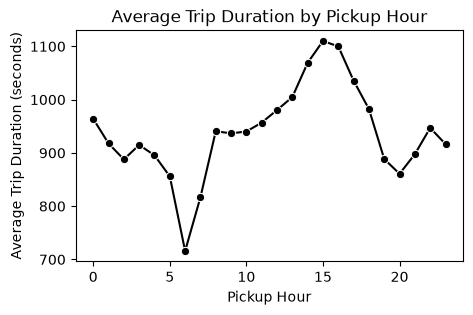

In [58]:
# Does trip duration vary by pickup hour of the day?

avg_duration_hour = (df.groupby('pickup_hour')['trip_duration'].mean().sort_index())


plt.figure(figsize = (5,3))
sns.lineplot(
    x=avg_duration_hour.index,
    y=avg_duration_hour.values,marker='o', color = 'black')

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (seconds)")
plt.title("Average Trip Duration by Pickup Hour")
plt.show()

- Trip duration is different from hour to hour
- Trip duration is very low at 5Am and increasing after 9 am high at 3-5pm  

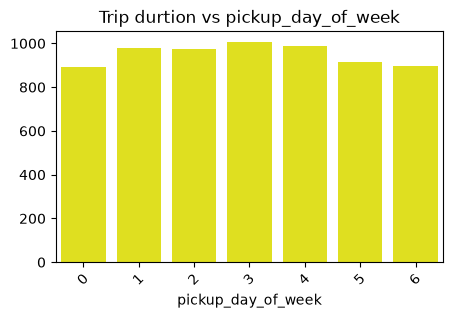

In [59]:
# Which day of the week has the more no.of average trips?
week_day_analysis = (df.groupby('pickup_day_of_week')['trip_duration'].mean().sort_index())

plt.figure(figsize = (5,3))
sns.barplot(x = week_day_analysis.index,y = week_day_analysis.values,color = 'yellow')
plt.title('Trip durtion vs pickup_day_of_week')
plt.xticks(rotation = 45)
plt.show()

- Friday,Thursday has long average trips
- Sunday has least average trips

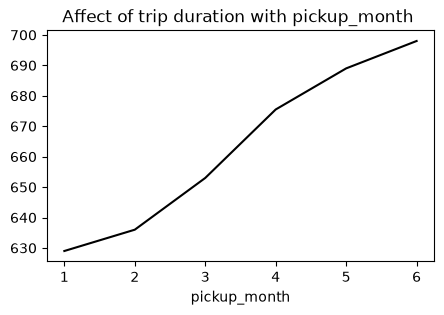

In [60]:
# How does demand change across months?
month_demand  = df.groupby('pickup_month')['trip_duration'].median().sort_index()

plt.figure(figsize = (5,3))
sns.lineplot(x = month_demand.index,y = month_demand.values,color = 'black')
plt.title('Affect of trip duration with pickup_month ')
plt.show()

## pickup_month is linearly related with trip duration 

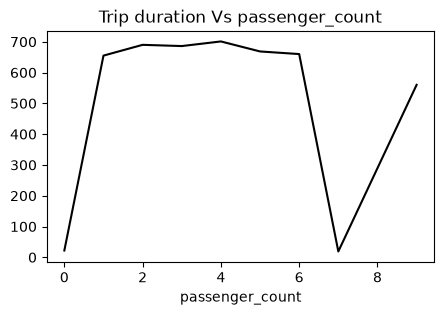

In [61]:
## Does passenger count affects the trip_duration 

n_passenger = df.groupby('passenger_count')['trip_duration'].median().sort_index()

plt.figure(figsize = (5,3))
sns.lineplot(x = n_passenger.index, y = n_passenger.values,color = 'black')
plt.title('Trip duration Vs passenger_count')
plt.show()

## Trip duration is stable with 1 to 6 passenger count  i.e  with approxiamtely 650 seconds 
## Trip duration is more with 4 passengers 

In [62]:
## Does passenger count affects the trip duration ?

df.groupby('passenger_count')['trip_duration'].agg(['count','mean','median'])

# As passenger count increases from 1 to 6, the average trip duration generally increases. However, the median trip duration remains relatively
# stable, suggesting that passenger count may have a weak or indirect relationship with trip duration rather than being a major determining factor.

,count,mean,median
passenger_count,,,
0,33,403.969697,22.0
1,517415,921.403438,655.0
2,105097,995.422191,690.0
3,29692,1026.482285,686.0
4,14050,1013.849181,701.0
5,38926,1085.312953,668.5
6,24107,1084.088232,660.0
7,1,19.000000,19.0
9,1,560.000000,560.0


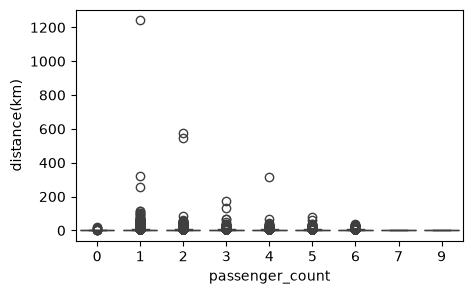

In [63]:
# Does Passenger count affect trip distance ?
plt.figure(figsize = (5,3))
sns.boxplot(x = df['passenger_count'],y = df['distance(km)'])
plt.show()

- single passenger went for a long distances
- taxi with 2,3,4,5,6,0 passengers also travelled long distances
- Taxi  travelled for short distance with 7 or 9 passengers

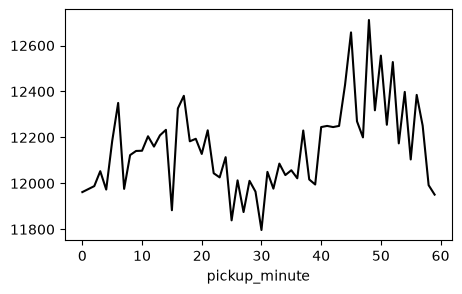

In [64]:
minute = df['pickup_minute'].value_counts().sort_index()
plt.figure(figsize = (5,3))
sns.lineplot(x = minute.index,y = minute.values,color = 'black')
plt.show()

- the pickups are at the last 20minutes  of the hour 

- Observing the uniform distibution 

##### Most of the trips are concentrated from lower Manhattan- upper Manhattan , and around Brooklyn, WilliamsBurg in NewYork City

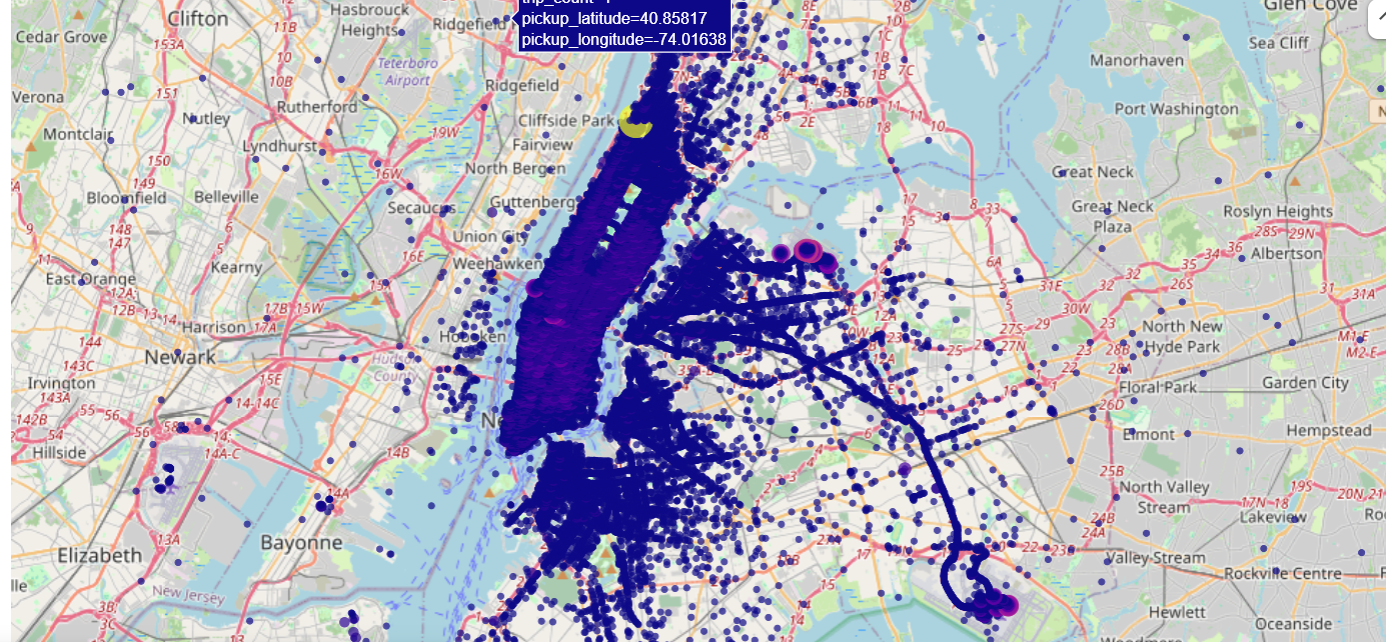

## Final Insights

1. Dataset Overview
- The dataset contains 729,322 NYC taxi trips with 11 features.
- The data mainly covers January to June 2016, few dropoff in july due to midnight trips 
- There are no missing values or duplicate records.
2. Trip Duration
- Most trips are short, with a few very long trips.
- Trip duration is right-skewed and contains some outliers.
3. Taxi Demand by Hour
- Taxi demand is low during the early morning.
- Demand increases during the day and is highest around 6 PM–10 PM.
- 6 PM to 8Pm  peak time where more no.of trips can takes place.
4. Weekly Demand
- Friday has the highest number of trips.
- Monday has the lowest number of trips.
- Taxi demand is generally higher toward the weekend.
5. Monthly Demand
- pickup_month is linearly related with trip duration
- March has the highest number of trips.
- Trip volume generally increases from January to March and then decreases slightly.
6. Passenger Count
- Most trips have only one passenger.
- Around 517,415 trips have one passenger.
- A few unusual passenger counts may be data errors.
7. Trip Distance
- Most trips cover short distances.
- Average distance is around 3.44 km, while the median is about 2.10 km.
- A small number of trips have unusually long distances.
8. Zero-Distance Trips
- Around 2,901 trips have zero calculated distance.
- These records may be caused by GPS or data-recording issues.
9. Passenger Count vs Distance
- Single-passenger trips are the most common.
- There is no clear relationship between passenger count and trip distance.
10. Pickup Locations
- Most pickups are concentrated in Manhattan.
- Some high-demand areas are also seen around Brooklyn/Williamsburg.
11. Pickup Minutes
- Trips are fairly evenly distributed across the minutes of an hour.
- Pickup hour is more useful than pickup minute for understanding demand.
12. Vendor Analysis
- Vendor 2 has more trips than Vendor 1.
- Vendor 2: 390,481 trips
- Vendor 1: 338,841 trips

In [65]:
df[df['distance(km)']!=0].shape

(726421, 24)

In [66]:
## removing entries with  distance is equal to zero

df = df[df['distance(km)']!=0]

In [67]:
## Converting the dataframe into csv for futher analysis

df.to_csv('cleaned_nyc.csv',index = False)

In [68]:
df1 = pd.read_csv('cleaned_nyc.csv')


df1.head(10)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day_of_week,pickup_day_of_month,pickup_hour,pickup_minute,drop_year,drop_month,drop_day_of_week,drop_day_of_month,drop_hour,drop_minute,distance(km)
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953920,40.778873,-73.963875,40.771164,N,400,2016,2,0,29,16,40,2016,2,0,29,16,47,1.199073
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988310,40.731743,-73.994750,40.694930,N,1100,2016,3,4,11,23,35,2016,3,4,11,23,53,4.129111
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721460,-73.948030,40.774918,N,1635,2016,2,6,21,17,59,2016,2,6,21,18,26,7.250753
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956780,40.780630,N,1141,2016,1,1,5,9,44,2016,1,1,5,10,3,2.361098
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708470,-73.988180,40.740630,N,848,2016,2,2,17,6,42,2016,2,2,17,6,56,4.328534
5,id1918069,2,2016-02-14 18:31:42,2016-02-14 18:55:57,2,-73.993614,40.751884,-73.995420,40.723860,N,1455,2016,2,6,14,18,31,2016,2,6,14,18,55,3.119711
6,id2429028,1,2016-04-20 20:30:14,2016-04-20 20:36:51,1,-73.965080,40.758915,-73.976810,40.764107,N,397,2016,4,2,20,20,30,2016,4,2,20,20,36,1.143979
7,id1663798,2,2016-06-19 16:48:14,2016-06-19 17:06:35,1,-73.963890,40.765434,-73.872430,40.774200,N,1101,2016,6,6,19,16,48,2016,6,6,19,17,6,7.763590
8,id2436943,2,2016-03-28 19:17:03,2016-03-28 19:48:29,2,-73.872890,40.774280,-73.979020,40.761880,N,1886,2016,3,0,28,19,17,2016,3,0,28,19,48,9.043648
9,id2933909,1,2016-04-10 22:01:41,2016-04-10 22:25:30,1,-73.987820,40.740982,-73.999150,40.686450,N,1429,2016,4,6,10,22,1,2016,4,6,10,22,25,6.138310


In [69]:
df.info()

<class 'pandas.DataFrame'>
Index: 726421 entries, 0 to 729321
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   id                   726421 non-null  str           
 1   vendor_id            726421 non-null  int8          
 2   pickup_datetime      726421 non-null  datetime64[us]
 3   dropoff_datetime     726421 non-null  datetime64[us]
 4   passenger_count      726421 non-null  int8          
 5   pickup_longitude     726421 non-null  float32       
 6   pickup_latitude      726421 non-null  float32       
 7   dropoff_longitude    726421 non-null  float32       
 8   dropoff_latitude     726421 non-null  float32       
 9   store_and_fwd_flag   726421 non-null  category      
 10  trip_duration        726421 non-null  int32         
 11  pickup_year          726421 non-null  int32         
 12  pickup_month         726421 non-null  int32         
 13  pickup_day_of_week   726421 no

In [70]:
df[df['distance(km)']==0]

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_year,pickup_month,pickup_day_of_week,pickup_day_of_month,pickup_hour,pickup_minute,drop_year,drop_month,drop_day_of_week,drop_day_of_month,drop_hour,drop_minute,distance(km)
